In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub
!pip install -r requirements.txt

%cd /content/drive/MyDrive/Capstone_Hripsime/Frameworks/DeepfakeBench
!pip install jedi
!python -m pip install -U pip setuptools wheel
!pip install -r requirements.txt
!pip install -e .

import sys

BASE = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks"
sys.path.insert(0, f"{BASE}/ForensicHub")
sys.path.insert(0, f"{BASE}/DeepfakeBench")
sys.path.insert(0, f"{BASE}/IMDLBenCo")

/content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/Capstone_Hripsime/Frameworks/ForensicHub
/content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/Capstone_Hripsime/Frameworks/DeepfakeBench
Obtaining file:///content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/Capstone_Hripsime/Frameworks/DeepfakeBench
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for deepfakebench (pyproject.toml) ... done
  Created wheel for deepfakebench: filename=deepfakebench-0.1.0-0.editable-py3-none-any.whl size=14517 sha256=c85ee060661c0d37dc24c4d8efa8a346f49c09ad1fce586728f1e7bcd65882a7
  Stored in directory: /tmp/pip-ephem-wheel-cache-z314ctrl/wheels/9f/69/83/09f777ca13410471b8e2a8431150d66b966538b5ec9615af42
Successfully built deepfakebench


In [3]:
import os, glob, json, random

TRAIN_DIR = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/Datasets/training_data"
VAL_DIR   = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/Datasets/validation_data"
TEST_DIR  = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/Datasets/publictest_data"

VAL_REF   = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/RDDC_References/validation_reference/reference.txt"
TEST_REF  = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/RDDC_References/publictest_reference/reference.txt"

STAGING = "/content/DiffusionForensics_Recons"
os.makedirs(STAGING, exist_ok=True)

IMG_EXTS = (".png", ".jpg", ".jpeg", ".webp", ".bmp", ".tif", ".tiff")

# ═══════════════════════════════════════════════════
# TRAINING — training_data_final
# ═══════════════════════════════════════════════════
train_items = []
for ext in IMG_EXTS:
    for p in glob.glob(os.path.join(TRAIN_DIR, f"*{ext}")):
        name = os.path.basename(p).lower()
        if "_real" in name:
            train_items.append({"path": p, "label": 0})
        elif "_fake" in name:
            train_items.append({"path": p, "label": 1})

random.seed(42)
random.shuffle(train_items)

n_real = sum(1 for x in train_items if x["label"] == 0)
n_fake = sum(1 for x in train_items if x["label"] == 1)
print(f"TRAIN: {len(train_items)} images  (real={n_real}, fake={n_fake})")

# ═══════════════════════════════════════════════════
# VALIDATION — validation_data_final + reference.txt
# Images: 0000.png, 0001.png, ...  Labels: 0=real, 1=fake
# ═══════════════════════════════════════════════════
with open(VAL_REF) as f:
    val_labels = [int(line.strip()) for line in f if line.strip()]

val_images = sorted(glob.glob(os.path.join(VAL_DIR, "*.*")))
val_images = [p for p in val_images if os.path.splitext(p)[1].lower() in IMG_EXTS]

assert len(val_images) == len(val_labels), \
    f"Mismatch: {len(val_images)} images vs {len(val_labels)} labels"

val_items = [{"path": p, "label": l} for p, l in zip(val_images, val_labels)]

n_real = sum(1 for x in val_items if x["label"] == 0)
n_fake = sum(1 for x in val_items if x["label"] == 1)
print(f"VAL:   {len(val_items)} images  (real={n_real}, fake={n_fake})")

# ═══════════════════════════════════════════════════
# TEST — publictest_data_final + reference.txt
# ═══════════════════════════════════════════════════
with open(TEST_REF) as f:
    test_labels = [int(line.strip()) for line in f if line.strip()]

test_images = sorted(glob.glob(os.path.join(TEST_DIR, "*.*")))
test_images = [p for p in test_images if os.path.splitext(p)[1].lower() in IMG_EXTS]

assert len(test_images) == len(test_labels), \
    f"Mismatch: {len(test_images)} images vs {len(test_labels)} labels"

test_items = [{"path": p, "label": l} for p, l in zip(test_images, test_labels)]

n_real = sum(1 for x in test_items if x["label"] == 0)
n_fake = sum(1 for x in test_items if x["label"] == 1)
print(f"TEST:  {len(test_items)} images  (real={n_real}, fake={n_fake})")

# ═══════════════════════════════════════════════════
# SAVE JSONs
# ═══════════════════════════════════════════════════
for name, data in [("train", train_items), ("val", val_items), ("test", test_items)]:
    out = os.path.join(STAGING, f"{name}.json")
    with open(out, "w") as f:
        json.dump(data, f)
    print(f"\n✓ {name}.json → {len(data)} items → {out}")


TRAIN: 1000 images  (real=500, fake=500)
VAL:   100 images  (real=50, fake=50)
TEST:  1000 images  (real=500, fake=500)

✓ train.json → 1000 items → /content/DiffusionForensics_Recons/train.json

✓ val.json → 100 items → /content/DiffusionForensics_Recons/val.json

✓ test.json → 1000 items → /content/DiffusionForensics_Recons/test.json


In [ ]:
# import shutil
# from pathlib import Path

# TEST_LOG_DIR = Path("/content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/resnet_test")

# if TEST_LOG_DIR.exists():
#     shutil.rmtree(TEST_LOG_DIR)
#     print("🧹 Old test logs deleted")

# TEST_LOG_DIR.mkdir(parents=True, exist_ok=True)
# print("✅ Fresh test log folder created:", TEST_LOG_DIR)

🧹 Old test logs deleted
✅ Fresh test log folder created: /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/resnet_test


In [ ]:
# %cd /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub

# !PYTHONPATH=$PWD MASTER_ADDR=127.0.0.1 MASTER_PORT=29601 \
# python -m ForensicHub.training_scripts.test \
# --config "ForensicHub/statics/aigc/resnet_test.yaml"


/content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/Capstone_Hripsime/Frameworks/ForensicHub
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
2.10.0+cu128
Current Torch version: 2.10
/usr/local/lib/python3.12/dist-packages/timm/optim/optim_factory.py:7: FutureWarning: Importing from timm.optim.optim_factory is deprecated, please import via timm.optim
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.optim", FutureWarning)
2026-04-17 16:26:07.046460: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776443167.068600    7468 cuda_dnn.cc:8579] Unable to register cuDNN fact

In [4]:
import os
import json
import numpy as np
import torch
from PIL import Image
from ForensicHub.registry import MODELS, build_from_registry

# =========================
# PATHS
# =========================
CHECKPOINT_PATH = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/resnet_train/checkpoint-19.pth"
TEST_JSON = "/content/DiffusionForensics_Recons/test.json"
OUT_RESULTS = "/content/DiffusionForensics_Recons/test_inference_results.json"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
THRESHOLD = 0.5   # change to 0.4349 if that is your chosen threshold
IMAGE_SIZE = 224

# =========================
# PREPROCESS
# =========================
def preprocess_pil(img, image_size=224):
    img = img.resize((image_size, image_size))
    arr = np.asarray(img).astype("float32") / 255.0
    arr = arr.transpose(2, 0, 1)  # HWC -> CHW

    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)[:, None, None]
    std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)[:, None, None]
    arr = (arr - mean) / std

    return torch.tensor(arr, dtype=torch.float32)

# =========================
# BUILD MODEL
# =========================
model_args = {
    "name": "Resnet50",
    "init_config": {
        "output_type": "label",
        "pretrained": False,
        "image_size": IMAGE_SIZE,
    }
}

model = build_from_registry(MODELS, model_args)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
state_dict = checkpoint["model"] if "model" in checkpoint else checkpoint
model.load_state_dict(state_dict, strict=False)
model.to(DEVICE)
model.eval()

# =========================
# LOAD TEST ITEMS
# =========================
with open(TEST_JSON, "r") as f:
    test_items = json.load(f)

results = []
skipped = []

# =========================
# INFERENCE
# =========================
with torch.no_grad():
    for item in test_items:
        path = item["path"]
        true_label = int(item["label"])

        try:
            img = Image.open(path).convert("RGB")
            x = preprocess_pil(img, image_size=IMAGE_SIZE).unsqueeze(0).to(DEVICE)

            input_dict = {
                "image": x,
                "label": torch.tensor([true_label], dtype=torch.float32).to(DEVICE),
                "mask": torch.ones(1, 1, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE),
            }

            out_dict = model(**input_dict)
            score = float(out_dict["pred_label"].view(-1)[0].item())
            pred = 1 if score >= THRESHOLD else 0

            results.append({
                "path": path,
                "true_label": true_label,
                "pred": pred,
                "score": score
            })

        except Exception as e:
            skipped.append({"path": path, "error": str(e)})

print("Processed:", len(results))
print("Skipped:", len(skipped))

with open(OUT_RESULTS, "w") as f:
    json.dump(results, f)

print("Saved:", OUT_RESULTS)

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


2.10.0+cu128
Current Torch version: 2.10
[build_from_registry] Creating model 'Resnet50' with args: {'output_type': 'label', 'pretrained': False, 'image_size': 224}
Processed: 1000
Skipped: 0
Saved: /content/DiffusionForensics_Recons/test_inference_results.json


ResNet public-test metrics
P:    0.5958
R:    0.4540
F1:   0.5153
Acc:  0.5730
AUC:  0.5989
------------------------------------------------------------
TP: 227
TN: 346
FP: 154
FN: 273
Correct: 573/1000
Wrong:   427/1000
Copied ResNet train log to: /content/drive/MyDrive/Capstone_Hripsime/submission/logs/resnet_train/log.txt

Saved ResNet artifacts:
 - /content/drive/MyDrive/Capstone_Hripsime/submission/test_outputs/resnet/preds.npy
 - /content/drive/MyDrive/Capstone_Hripsime/submission/test_outputs/resnet/labels.npy
 - /content/drive/MyDrive/Capstone_Hripsime/submission/test_outputs/resnet/resnet_test_inference_results.json
 - /content/drive/MyDrive/Capstone_Hripsime/submission/test_outputs/resnet/metadata.json
 - /content/drive/MyDrive/Capstone_Hripsime/submission/results/figures/resnet_test_confusion_matrix_reproduced.jpg


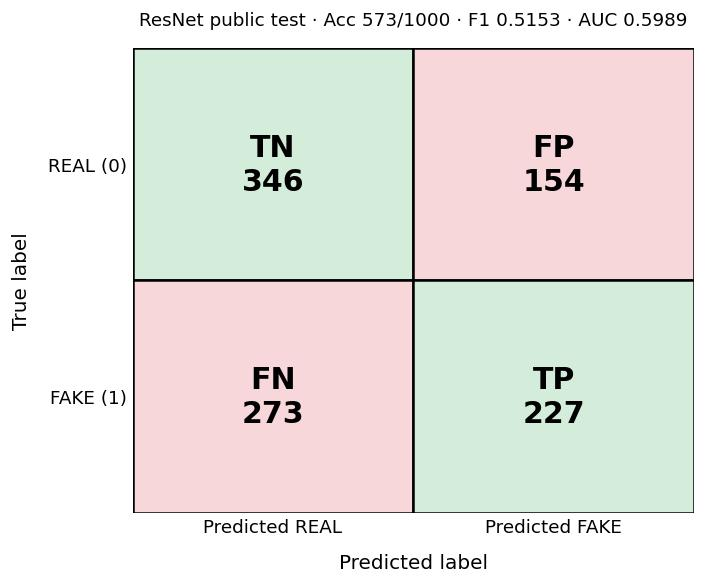

In [5]:
# ============================================================
# ResNet post-inference: metrics + confusion matrix + export artifacts
# ============================================================

%matplotlib inline

import os
import json
import shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
)
from IPython.display import Image, display

# =========================
# PATHS
# =========================

RESULTS_JSON = "/content/DiffusionForensics_Recons/test_inference_results.json"

SUBMISSION_ROOT = Path("/content/drive/MyDrive/Capstone_Hripsime/submission")
RESNET_OUT = SUBMISSION_ROOT / "test_outputs" / "resnet"
RESNET_OUT.mkdir(parents=True, exist_ok=True)

RESNET_LOG_OUT = SUBMISSION_ROOT / "logs" / "resnet_train"
RESNET_LOG_OUT.mkdir(parents=True, exist_ok=True)

FIG_DIR = SUBMISSION_ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

BASE = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks"
CHECKPOINT_PATH = f"{BASE}/ForensicHub/log/resnet_train/checkpoint-19.pth"
LOG_PATH = f"{BASE}/ForensicHub/log/resnet_train/log.txt"

THRESHOLD = 0.5

# =========================
# LOAD RESULTS
# =========================

with open(RESULTS_JSON, "r") as f:
    results = json.load(f)

if len(results) == 0:
    raise RuntimeError("ResNet results JSON is empty.")

y_true = np.array([int(r["true_label"]) for r in results], dtype=int)
y_score = np.array([float(r["score"]) for r in results], dtype=float)

# Direct score only: score is fake probability
y_pred = (y_score >= THRESHOLD).astype(int)

# =========================
# METRICS
# =========================

precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
acc = accuracy_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_score)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
TN, FP, FN, TP = cm.ravel()

total = TP + TN + FP + FN
correct = TP + TN
wrong = FP + FN

print("=" * 60)
print("ResNet public-test metrics")
print("=" * 60)
print(f"P:    {precision:.4f}")
print(f"R:    {recall:.4f}")
print(f"F1:   {f1:.4f}")
print(f"Acc:  {acc:.4f}")
print(f"AUC:  {auc:.4f}")
print("-" * 60)
print(f"TP: {TP}")
print(f"TN: {TN}")
print(f"FP: {FP}")
print(f"FN: {FN}")
print(f"Correct: {correct}/{total}")
print(f"Wrong:   {wrong}/{total}")
print("=" * 60)

# =========================
# SAVE ARTIFACTS FOR ONE-COMMAND REPRODUCTION
# =========================

np.save(RESNET_OUT / "preds.npy", y_score)
np.save(RESNET_OUT / "labels.npy", y_true)

with open(RESNET_OUT / "resnet_test_inference_results.json", "w") as f:
    json.dump(results, f, indent=2)

metadata = {
    "model": "ResNet50",
    "threshold": THRESHOLD,
    "checkpoint_path": CHECKPOINT_PATH,
    "log_path": LOG_PATH,
    "source_results_json": RESULTS_JSON,
    "metrics": {
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "accuracy": float(acc),
        "auc": float(auc),
    },
    "confusion_matrix": {
        "TP": int(TP),
        "TN": int(TN),
        "FP": int(FP),
        "FN": int(FN),
    },
    "num_items": int(len(y_true)),
}

with open(RESNET_OUT / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

if os.path.exists(LOG_PATH):
    shutil.copy2(LOG_PATH, RESNET_LOG_OUT / "log.txt")
    print("Copied ResNet train log to:", RESNET_LOG_OUT / "log.txt")
else:
    print("WARNING: ResNet train log not found:", LOG_PATH)

# =========================
# PLOT SAME-STYLE CONFUSION MATRIX
# =========================

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor("white")

cell_labels = [["TN", "FP"], ["FN", "TP"]]
cell_values = [[TN, FP], [FN, TP]]
cell_colors = [
    ["#d4edda", "#f8d7da"],
    ["#f8d7da", "#d4edda"],
]

for i in range(2):
    for j in range(2):
        ax.add_patch(
            plt.Rectangle(
                (j, 1 - i),
                1,
                1,
                facecolor=cell_colors[i][j],
                edgecolor="black",
                linewidth=1.5,
            )
        )
        ax.text(
            j + 0.5,
            1 - i + 0.5,
            f"{cell_labels[i][j]}\n{cell_values[i][j]}",
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold",
            color="black",
        )

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_yticks([1.5, 0.5])

ax.set_xticklabels(["Predicted REAL", "Predicted FAKE"], fontsize=11)
ax.set_yticklabels(["REAL (0)", "FAKE (1)"], fontsize=11)

ax.set_xlabel("Predicted label", fontsize=12, labelpad=10)
ax.set_ylabel("True label", fontsize=12, labelpad=10)
ax.tick_params(length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    f"ResNet public test · Acc {correct}/{total} · F1 {f1:.4f} · AUC {auc:.4f}",
    fontsize=11,
    pad=14,
)

plt.tight_layout()

fig_path = FIG_DIR / "resnet_test_confusion_matrix_reproduced.jpg"
plt.savefig(fig_path, dpi=120, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.close(fig)

print("\nSaved ResNet artifacts:")
print(" -", RESNET_OUT / "preds.npy")
print(" -", RESNET_OUT / "labels.npy")
print(" -", RESNET_OUT / "resnet_test_inference_results.json")
print(" -", RESNET_OUT / "metadata.json")
print(" -", fig_path)

display(Image(filename=str(fig_path)))

Test F1 threshold: 0.5000, result: 0.5153
Test AUC: 0.5989
════════════════════════════════════════
  Confusion Matrix Results
════════════════════════════════════════
  TP (fake correctly detected) : 227
  TN (real correctly detected) : 346
  FP (real wrongly called fake): 154
  FN (fake wrongly called real): 273
────────────────────────────────────────
  Accuracy  : 57.3%
  Precision : 59.6%
  Recall    : 45.4%
  F1 Score  : 51.5%
════════════════════════════════════════


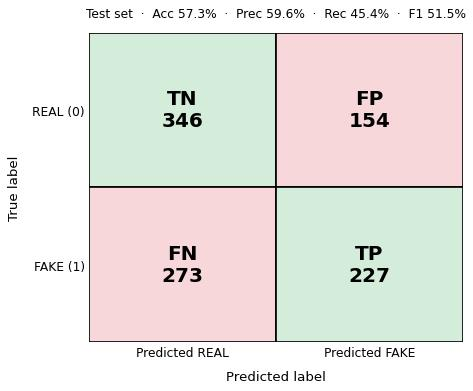

In [ ]:
%matplotlib inline
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score
from IPython.display import Image, display

RESULTS_JSON = "/content/DiffusionForensics_Recons/test_inference_results.json"
THRESHOLD = 0.5  # keep same threshold as inference

with open(RESULTS_JSON, "r") as f:
    results = json.load(f)

y_true = np.array([r["true_label"] for r in results])
y_pred = np.array([r["pred"] for r in results])
y_score = np.array([r["score"] for r in results])

f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_score)
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

TN, FP, FN, TP = cm.ravel()

total = TP + TN + FP + FN
accuracy = (TP + TN) / total if total > 0 else 0.0
precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

print(f"Test F1 threshold: {THRESHOLD:.4f}, result: {f1:.4f}")
print(f"Test AUC: {auc:.4f}")


print(f"{'═'*40}")
print(f"  Confusion Matrix Results")
print(f"{'═'*40}")
print(f"  TP (fake correctly detected) : {TP}")
print(f"  TN (real correctly detected) : {TN}")
print(f"  FP (real wrongly called fake): {FP}")
print(f"  FN (fake wrongly called real): {FN}")
print(f"{'─'*40}")
print(f"  Accuracy  : {accuracy*100:.1f}%")
print(f"  Precision : {precision*100:.1f}%")
print(f"  Recall    : {recall*100:.1f}%")
print(f"  F1 Score  : {f1*100:.1f}%")
print(f"{'═'*40}")

# Styled confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor("white")

cell_labels = [["TN", "FP"], ["FN", "TP"]]
cell_values = [[TN, FP], [FN, TP]]
cell_colors = [
    ["#d4edda", "#f8d7da"],  # TN green, FP red
    ["#f8d7da", "#d4edda"]   # FN red, TP green
]

for i in range(2):
    for j in range(2):
        ax.add_patch(
            plt.Rectangle(
                (j, 1 - i), 1, 1,
                facecolor=cell_colors[i][j],
                edgecolor="black",
                linewidth=1.5
            )
        )
        ax.text(
            j + 0.5, 1 - i + 0.5,
            f"{cell_labels[i][j]}\n{cell_values[i][j]}",
            ha="center", va="center",
            fontsize=18, fontweight="bold", color="black"
        )

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_yticks([0.5, 1.5])
ax.set_xticklabels(["Predicted REAL", "Predicted FAKE"], fontsize=11)
ax.set_yticklabels(["FAKE (1)", "REAL (0)"], fontsize=11)
ax.set_xlabel("Predicted label", fontsize=12, labelpad=10)
ax.set_ylabel("True label", fontsize=12, labelpad=10)
ax.tick_params(length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    f"Test set  ·  "
    f"Acc {accuracy*100:.1f}%  ·  "
    f"Prec {precision*100:.1f}%  ·  "
    f"Rec {recall*100:.1f}%  ·  "
    f"F1 {f1*100:.1f}%",
    fontsize=11,
    pad=14
)

plt.tight_layout()
plt.savefig("test_confusion_matrix.jpg", dpi=80, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.close(fig)
display(Image("test_confusion_matrix.jpg"))

PublicTest: 573/1000 correct (57.3% accuracy)
REAL images: 500  |  FAKE images: 500
Well detected: 573  |  Badly detected: 427
TP=227, TN=346, FP=154, FN=273

REAL accuracy: 69.20%
FAKE accuracy: 45.40%
FAKE precision: 0.5958
FAKE recall: 0.4540
FAKE F1: 0.5153


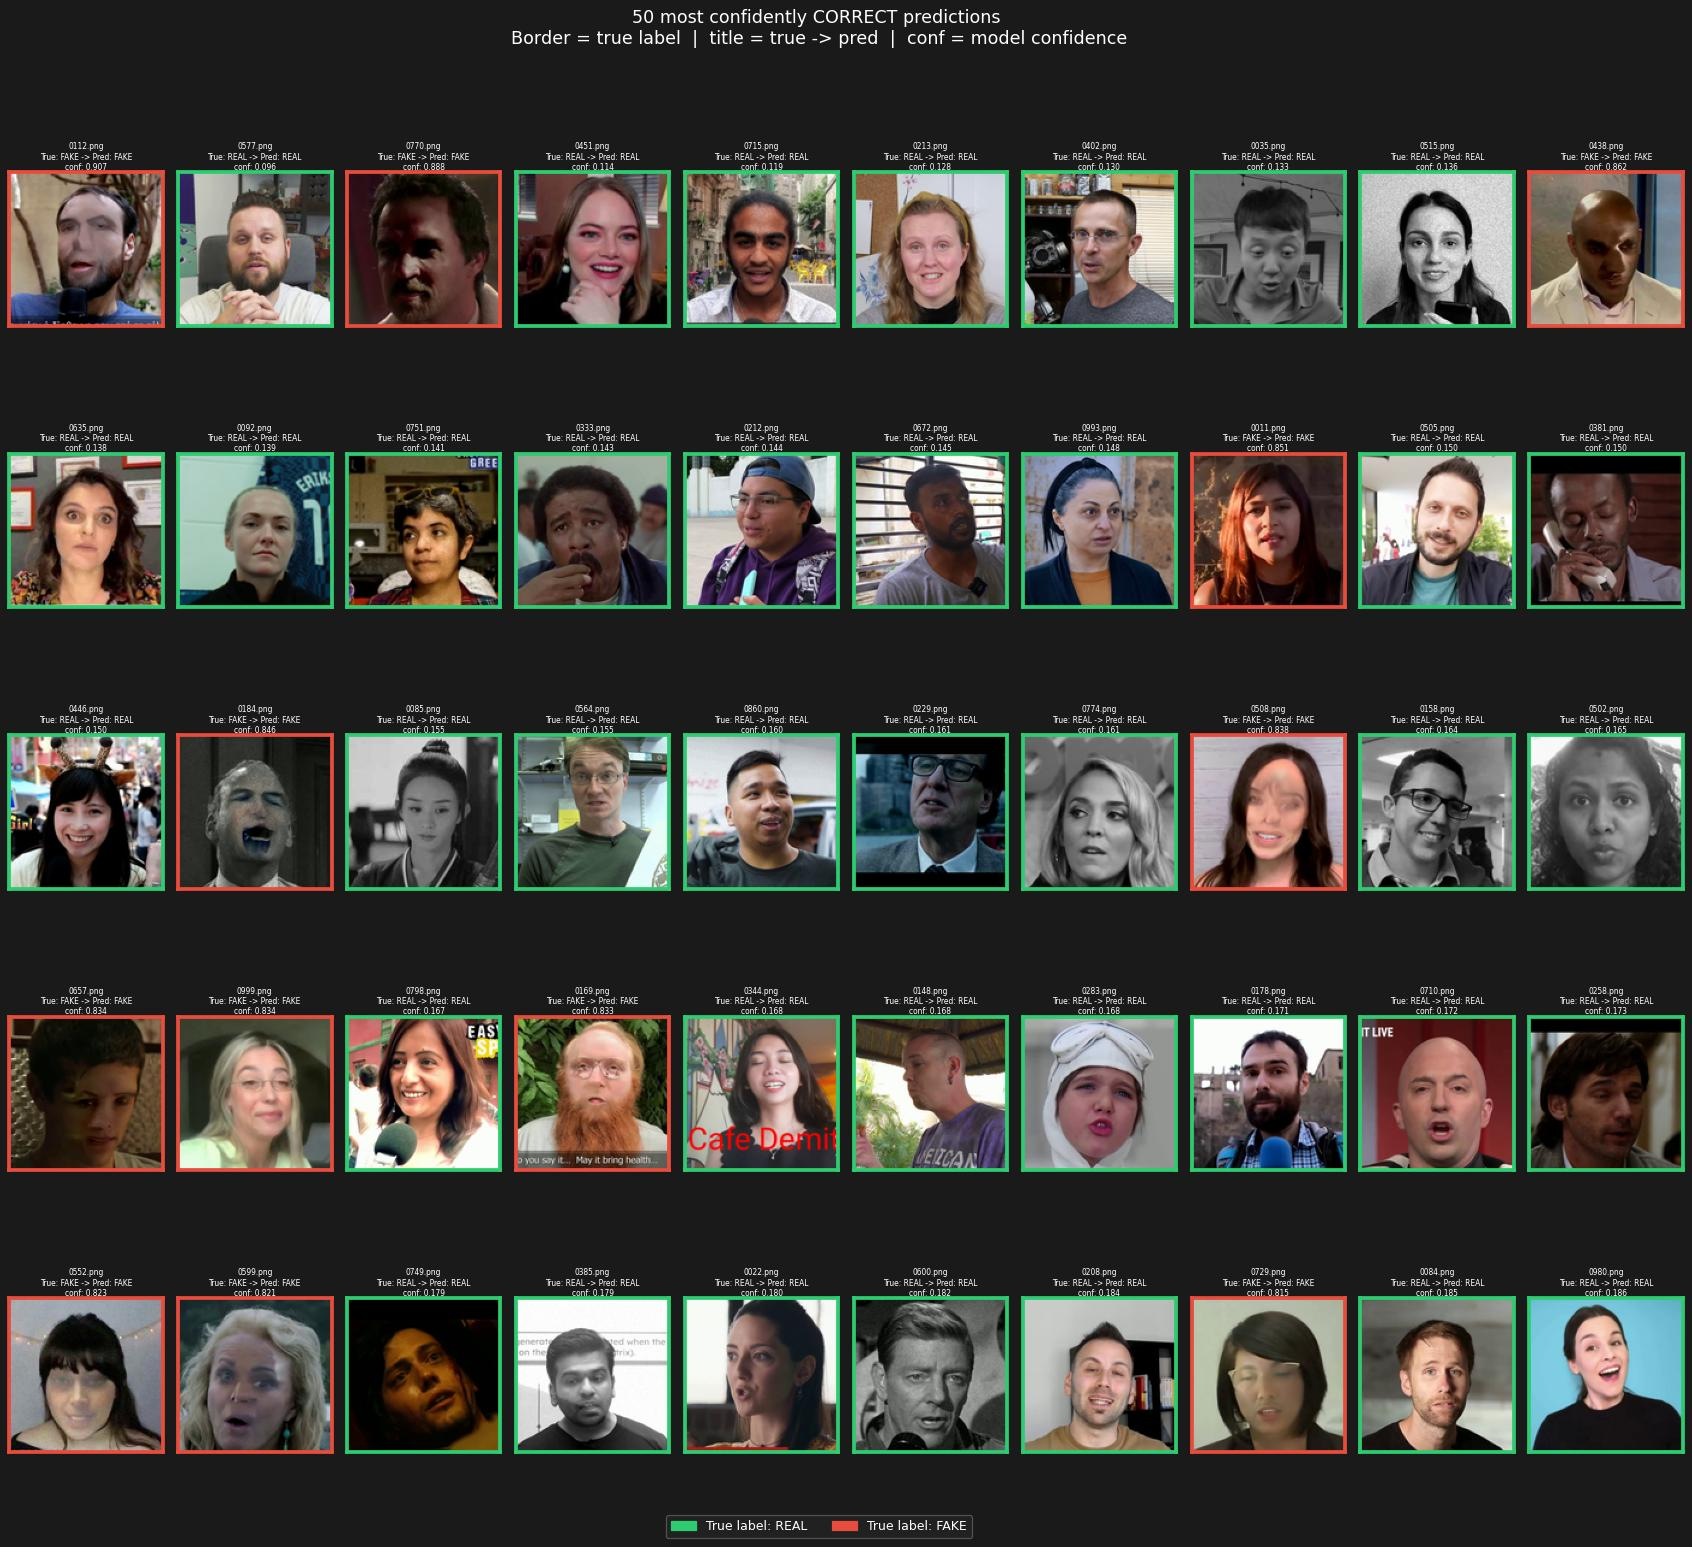

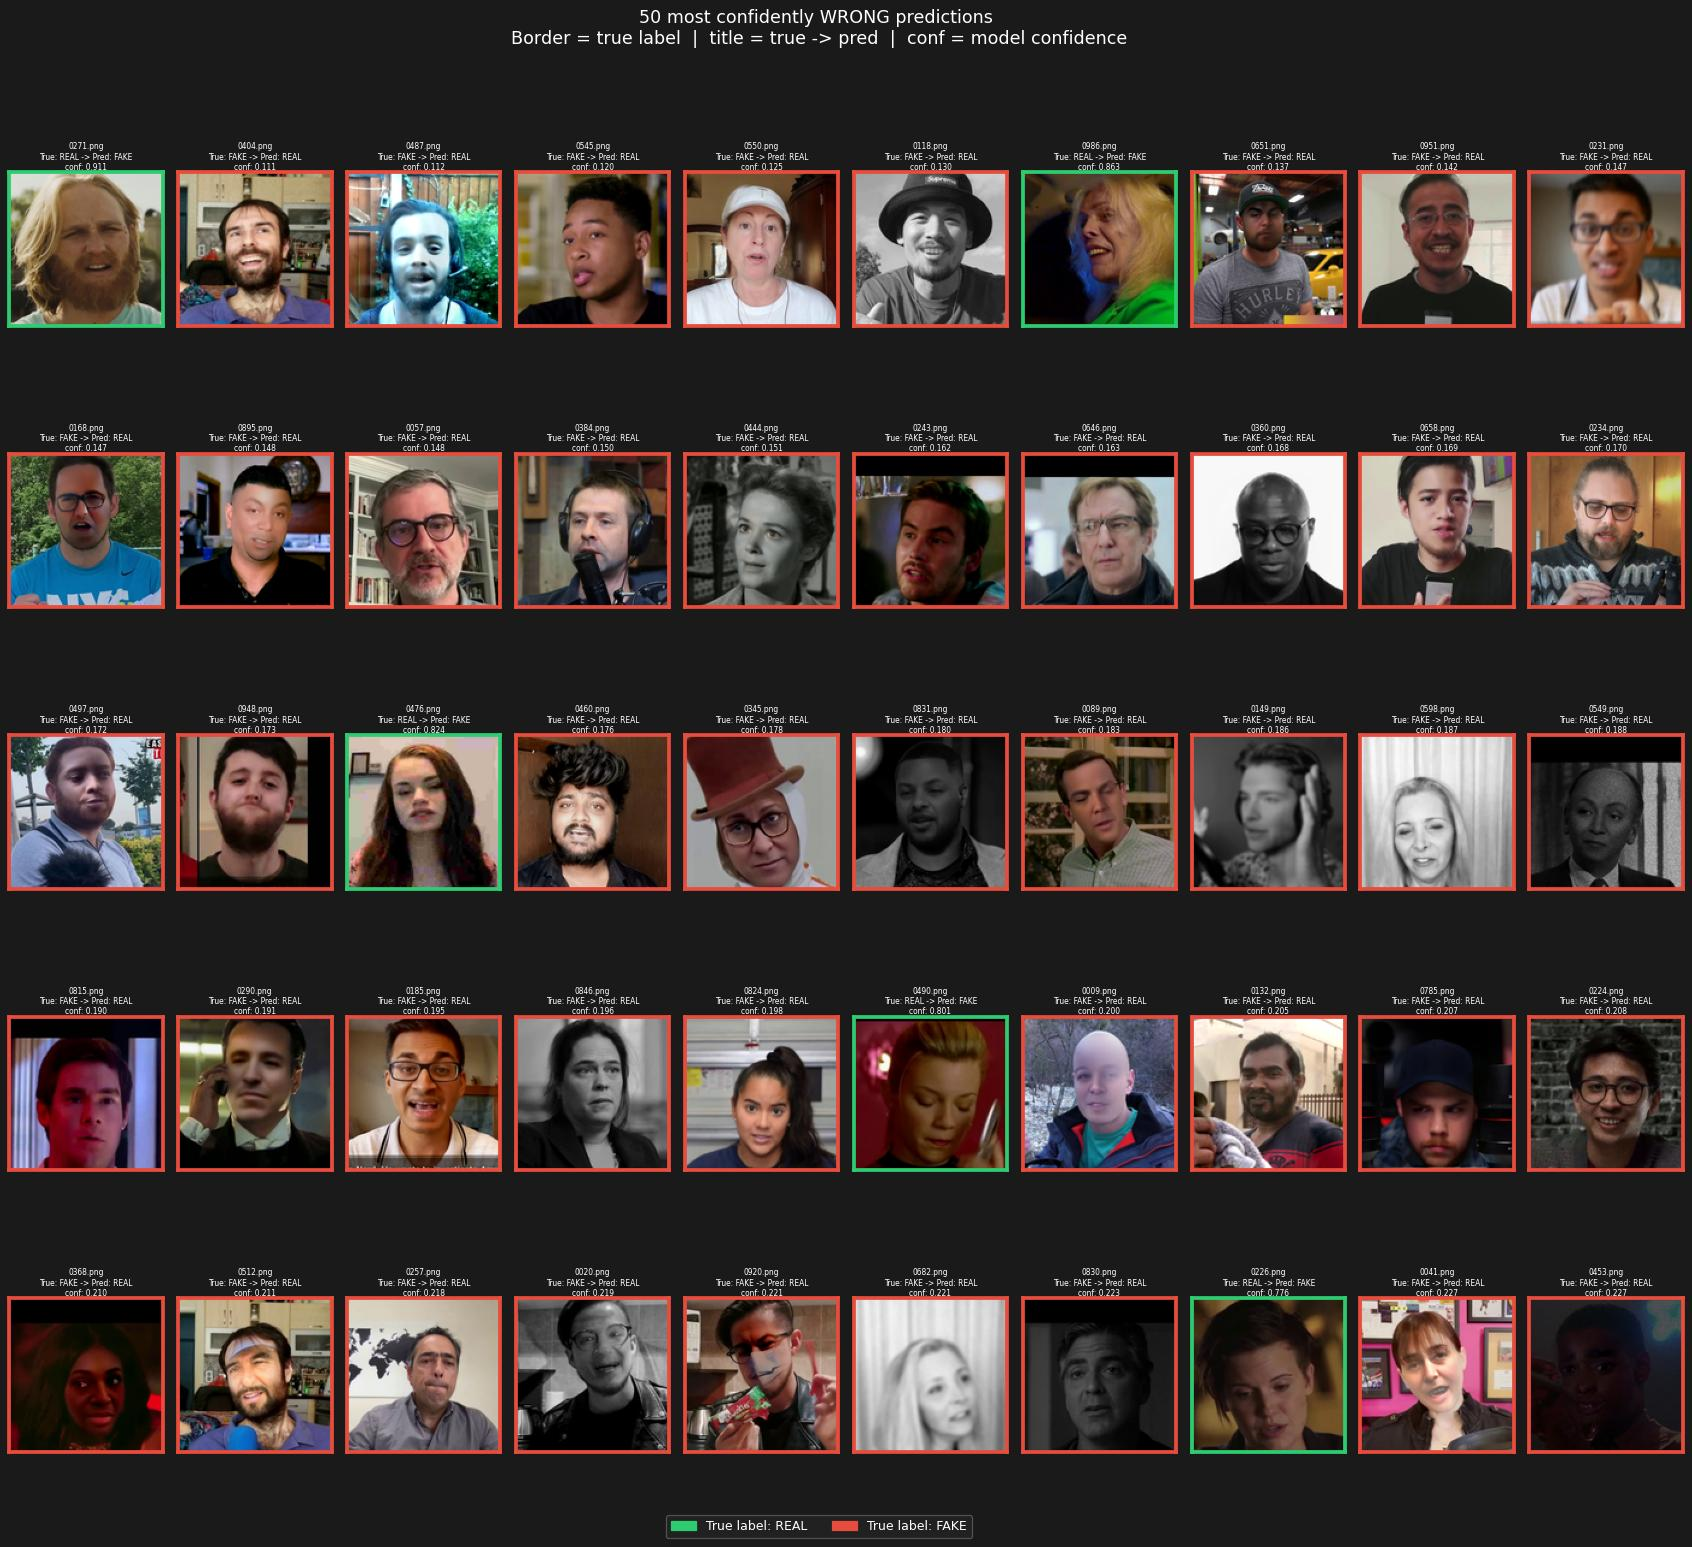

In [ ]:
# ── Badly / Well Detected — PublicTest ──

%matplotlib inline

import os
import json
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import Image, display

# ── Load test results ─────────────────────────────────────────────────────────
RESULTS_JSON = "/content/DiffusionForensics_Recons/test_inference_results.json"

with open(RESULTS_JSON, "r") as f:
    results = json.load(f)

# ── Build correct/incorrect using "score" key from test JSON ──────────────────
for r in results:
    r["confidence"] = r["score"]                       # unify key name
    r["correct"] = (r["pred"] == r["true_label"])

total = len(results)
n_correct = sum(r["correct"] for r in results)
accuracy = 100 * n_correct / total

well  = [r for r in results if r["correct"]]
badly = [r for r in results if not r["correct"]]

well_sorted  = sorted(well,  key=lambda x: abs(x["confidence"] - 0.5), reverse=True)
badly_sorted = sorted(badly, key=lambda x: abs(x["confidence"] - 0.5), reverse=True)

well_sample  = well_sorted[:50]
badly_sample = badly_sorted[:50]

n_real = sum(r["true_label"] == 0 for r in results)
n_fake = sum(r["true_label"] == 1 for r in results)

tp = sum((r["true_label"] == 1 and r["pred"] == 1) for r in results)
tn = sum((r["true_label"] == 0 and r["pred"] == 0) for r in results)
fp = sum((r["true_label"] == 0 and r["pred"] == 1) for r in results)
fn = sum((r["true_label"] == 1 and r["pred"] == 0) for r in results)

real_acc = 100 * tn / max(1, n_real)
fake_acc = 100 * tp / max(1, n_fake)
precision_fake = tp / max(1, tp + fp)
recall_fake = tp / max(1, tp + fn)
f1_fake = 2 * precision_fake * recall_fake / max(1e-12, precision_fake + recall_fake)

print(f"PublicTest: {n_correct}/{total} correct ({accuracy:.1f}% accuracy)")
print(f"REAL images: {n_real}  |  FAKE images: {n_fake}")
print(f"Well detected: {len(well)}  |  Badly detected: {len(badly)}")
print(f"TP={tp}, TN={tn}, FP={fp}, FN={fn}")
print(f"\nREAL accuracy: {real_acc:.2f}%")
print(f"FAKE accuracy: {fake_acc:.2f}%")
print(f"FAKE precision: {precision_fake:.4f}")
print(f"FAKE recall: {recall_fake:.4f}")
print(f"FAKE F1: {f1_fake:.4f}")

# ── Helpers ───────────────────────────────────────────────────────────────────
def label_str(l):
    return "REAL" if l == 0 else "FAKE"

def load_thumb(path, size=128):
    img = PILImage.open(path).convert("RGB")
    w, h = img.size
    side = min(w, h)
    img = img.crop(((w - side) // 2, (h - side) // 2,
                    (w + side) // 2, (h + side) // 2))
    return img.resize((size, size), PILImage.LANCZOS)

def make_grid(samples, title, filename):
    n = len(samples)
    cols = 10
    rows = max(1, (n + cols - 1) // cols)

    fig, axes = plt.subplots(rows, cols, figsize=(24, rows * 3.5))
    fig.patch.set_facecolor('#1a1a1a')

    if rows == 1:
        axes = [axes]

    for idx, ax in enumerate([a for row in axes for a in row]):
        if idx >= n:
            ax.axis('off')
            continue

        r = samples[idx]
        try:
            ax.imshow(load_thumb(r["path"]))
        except Exception:
            ax.set_facecolor('#333')
            ax.text(0.5, 0.5, 'error', ha='center', va='center',
                    color='white', fontsize=7, transform=ax.transAxes)

        true_color = '#2ecc71' if r["true_label"] == 0 else '#e74c3c'
        for spine in ax.spines.values():
            spine.set_edgecolor(true_color)
            spine.set_linewidth(3)

        ax.set_xticks([]); ax.set_yticks([])

        fname = os.path.basename(r["path"])
        ax.set_title(
            f"{fname}\nTrue: {label_str(r['true_label'])} -> Pred: {label_str(r['pred'])}\n"
            f"conf: {r['confidence']:.3f}",
            fontsize=6, color='white', pad=2
        )

    real_p = mpatches.Patch(color='#2ecc71', label='True label: REAL')
    fake_p = mpatches.Patch(color='#e74c3c', label='True label: FAKE')
    fig.legend(handles=[real_p, fake_p], loc='lower center', ncol=2,
               fontsize=10, framealpha=0.3, facecolor='#333',
               labelcolor='white', bbox_to_anchor=(0.5, 0.005))

    fig.suptitle(title, fontsize=14, color='white', fontweight='medium')
    plt.subplots_adjust(hspace=0.7, wspace=0.1, top=0.88, bottom=0.06)

    plt.savefig(filename, dpi=90, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close(fig)
    display(Image(filename))



# ── Plots ─────────────────────────────────────────────────────────────────────
make_grid(
    well_sample,
    title=f'50 most confidently CORRECT predictions \n'
          'Border = true label  |  title = true -> pred  |  conf = model confidence',
    filename='well_detected_test.jpg'
)

make_grid(
    badly_sample,
    title=f'50 most confidently WRONG predictions \n'
          'Border = true label  |  title = true -> pred  |  conf = model confidence',
    filename='badly_detected_test.jpg'
)


In [ ]:
# Step 1 — install nbconvert (already available in Colab but just in case)
!pip install nbconvert -q

NOTEBOOK_PATH = "/content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/Test Challange Forensichub.ipynb"
OUTPUT_DIR    = "/content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/HTML Notebooks"

!jupyter nbconvert \
    --to html \
    --embed-images \
    --output-dir "{OUTPUT_DIR}" \
    "{NOTEBOOK_PATH}"

print("Done — check your Drive for the .html file")

[NbConvertApp] Converting notebook /content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/Test Challange Forensichub.ipynb to html
[NbConvertApp] Writing 400982 bytes to /content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/HTML Notebooks/Test Challange Forensichub.html
Done — check your Drive for the .html file
